In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('prj_data_cleaned.csv')
df.head()

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,멤버십등급_Encoder,거주지역_경기,거주지역_기타,...,거주지역_서울,성별_남,성별_여,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y,Buy
0,C0001,22.0,실버,-0.329352,-0.183592,3.3,1,3,0,0,...,0,1,0,0,1,0,0,1,0,-0.298804
1,C0002,58.0,VIP,0.783521,2.273239,4.7,0,0,0,0,...,0,0,1,0,0,1,0,0,1,-0.244679
2,C0003,52.0,브론즈,-0.631960,-1.076986,3.3,0,2,0,1,...,0,0,1,0,1,0,0,0,1,-0.237769
3,C0004,40.0,실버,-0.245946,-1.076986,3.8,0,3,1,0,...,0,0,1,0,1,0,0,1,0,0.439634
4,C0005,40.0,골드,0.096827,-0.183592,4.9,0,1,1,0,...,0,1,0,0,0,1,0,1,0,0.021720


# 1. 데이터 기초 특성 파악

In [65]:
df.shape

(500, 22)

In [66]:
df.dtypes

고객ID                 str
나이               float64
멤버십등급                str
월평균구매금액          float64
구매횟수             float64
리뷰점수             float64
이탈여부               int64
멤버십등급_Encoder      int64
거주지역_경기            int64
거주지역_기타            int64
거주지역_대구            int64
거주지역_부산            int64
거주지역_서울            int64
성별_남               int64
성별_여               int64
가입경로_광고            int64
가입경로_앱             int64
가입경로_웹             int64
가입경로_지인추천          int64
쿠폰사용여부_N           int64
쿠폰사용여부_Y           int64
Buy              float64
dtype: object

In [67]:
df.describe()

,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부,멤버십등급_Encoder,거주지역_경기,거주지역_기타,거주지역_대구,거주지역_부산,거주지역_서울,성별_남,성별_여,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y,Buy
count,500.000000,5.000000e+02,5.000000e+02,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,43.195652,6.394885e-17,-2.131628e-17,3.736632,0.380000,1.842000,0.24600,0.106000,0.178000,0.160000,0.310000,0.460000,0.540000,0.160000,0.416000,0.300000,0.124000,0.620000,0.380000,7.460699e-17
std,14.384666,1.001002e+00,1.001002e+00,0.540323,0.485873,0.960667,0.43111,0.308146,0.382896,0.366973,0.462956,0.498897,0.498897,0.366973,0.493387,0.458717,0.329912,0.485873,0.485873,1.001002e+00
min,18.000000,-7.396747e-01,-1.523682e+00,2.500000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.074030e-01
25%,32.000000,-4.644057e-01,-8.536373e-01,3.400000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.070262e-01
50%,43.195652,-2.157524e-01,-1.835923e-01,3.700000,0.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-2.048039e-01
75%,56.000000,1.588185e-01,5.422898e-01,4.100000,1.000000,3.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,-5.594343e-02
max,69.000000,7.978910e+00,2.943284e+00,5.000000,1.000000,3.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.227571e+01


In [68]:
num_cols_na = df.select_dtypes(include='number').columns
cat_cols_na = df.select_dtypes(exclude='number').columns
num_cols_na,cat_cols_na

(Index(['나이', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부', '멤버십등급_Encoder', '거주지역_경기',
        '거주지역_기타', '거주지역_대구', '거주지역_부산', '거주지역_서울', '성별_남', '성별_여', '가입경로_광고',
        '가입경로_앱', '가입경로_웹', '가입경로_지인추천', '쿠폰사용여부_N', '쿠폰사용여부_Y', 'Buy'],
       dtype='str'),
 Index(['고객ID', '멤버십등급'], dtype='str'))

In [69]:
df['거주지역_기타'].value_counts()

거주지역_기타
0    447
1     53
Name: count, dtype: int64

# 2. 단변량/분표 시각화

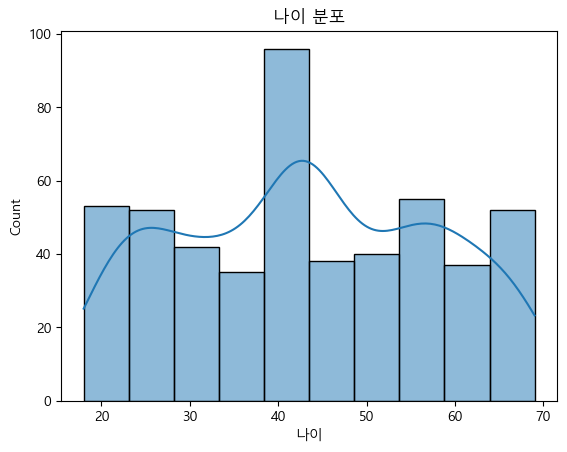

In [70]:
# 수치형 변수 분포 형태
sns.histplot(df['나이'], kde=True)
plt.title('나이 분포')
plt.show()

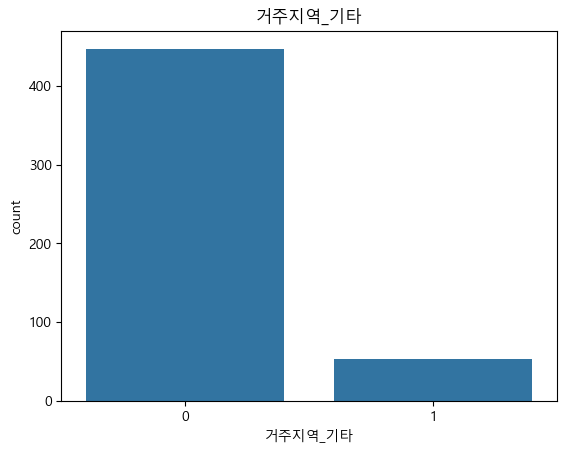

In [71]:
# 범주형 변수 분포 확인
sns.countplot(x='거주지역_기타', data=df)
plt.title('거주지역_기타')
plt.show()

시각화한 결과를 바탕으로 해석해보면 나이는 다양하게 분포되어 있고 거지주역은 수도권 지역에 거의 몰려 있습니다.

# 3. 상관관계 및 이변량 분석

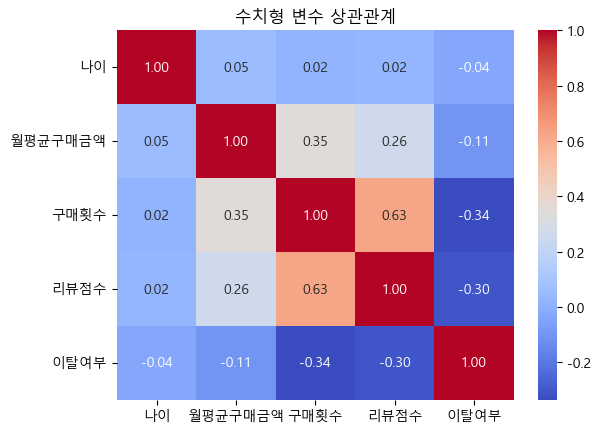

In [72]:
# 수치형 변수 corr로 계산 -> heatmap으로 시각화
corr = df[['나이', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부']].corr(numeric_only=True)

sns.heatmap(data=corr, annot=True,fmt='.2f', cmap='coolwarm')
plt.title('수치형 변수 상관관계')
plt.show()

In [73]:
np.ones(corr.shape)

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

In [74]:
np.triu(np.ones(corr.shape), k=1)

array([[0., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1.],
       [0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0.]])

In [75]:
np.triu(np.ones(corr.shape), k=1).astype(bool)

array([[False,  True,  True,  True,  True],
       [False, False,  True,  True,  True],
       [False, False, False,  True,  True],
       [False, False, False, False,  True],
       [False, False, False, False, False]])

In [76]:
corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)) 

,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부
나이,NaN,0.051332,0.018422,0.024417,-0.035966
월평균구매금액,NaN,NaN,0.352021,0.261078,-0.105813
구매횟수,NaN,NaN,NaN,0.626640,-0.336072
리뷰점수,NaN,NaN,NaN,NaN,-0.304883
이탈여부,NaN,NaN,NaN,NaN,NaN


In [77]:
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()

In [78]:
top_pair = corr_pairs.abs().sort_values(ascending=False).index[0]
print(f'최고 상관 변수 쌍 : {top_pair} r={corr.loc[top_pair]}')

최고 상관 변수 쌍 : ('구매횟수', '리뷰점수') r=0.6266398118083552


In [79]:
top_pair

('구매횟수', '리뷰점수')

Text(0.5, 1.0, '구매횟수 vs 리뷰점수')

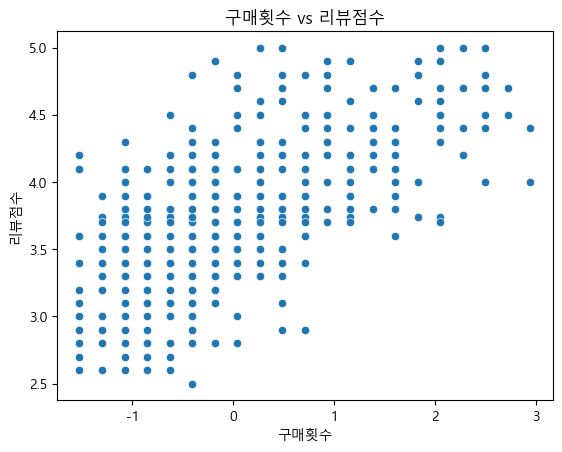

In [80]:
# scatterplot으로 관계 시각화
sns.scatterplot(data=df, x=top_pair[0], y=top_pair[1])
plt.title(f'{top_pair[0]} vs {top_pair[1]}')

구매 횟수가 늘어날 수록 리뷰 점수가 높게 분포되어 있는 걸 알 수 있다

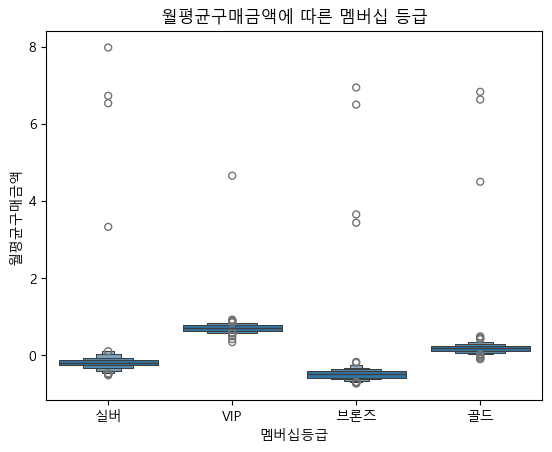

In [81]:
sns.boxenplot(data=df, x='멤버십등급', y='월평균구매금액')
plt.title('월평균구매금액에 따른 멤버십 등급')
plt.show()

평균적으로 사용한 구매금액은 VIP - 골드 - 실버 - 브론즈 순으로 나타나지만 오히려 극단적 이상치는 브론즈,실버,골드에서 다수 관찰된다

# 4. 그룹별 비교 분석 및 인사이트 추출

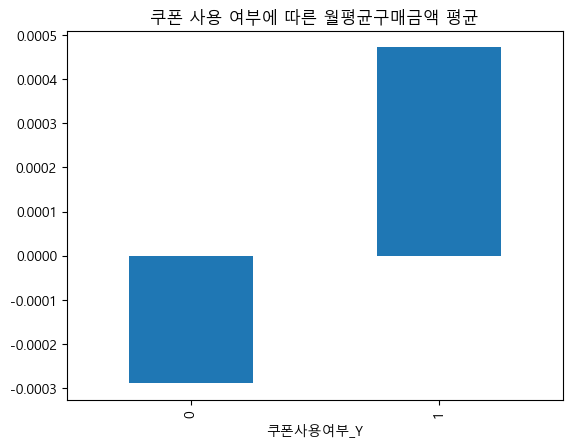

In [83]:
g1 = df.groupby('쿠폰사용여부_Y')['월평균구매금액'].mean()

g1.plot(kind='bar')
plt.title('쿠폰 사용 여부에 따른 월평균구매금액 평균')
plt.show()

남자보다 여자가 월 평균 소비 금액이 더 높으 것으로 나타난다

- 리뷰점수가 높을 수록 재방문 횟수가 증가하는 걸로 보아 서비스가 중요하다는 것을 알 수 있다.
- VIP등급은 이상치가 적고 평균금액이 큰 반면 골드, 실버, 브론즈 등급 순으로 평균 금액이 크고 극단적 이상치가 나타나는 걸로 보아 최근에 구매를 시작한 신규 고객이너가 아직 산정 주기가 돌아오지 않아 하위 등급에 머물러 있는 잠재적 vip가 있을 것으로 추정된다